## Introduction

- This retail dataset contains **3,900 customer transaction records** with demographic and purchase-related information.  
- Key features include **Age, Gender, Product Category, Purchase Amount, Season, Subscription Status, Payment Method, Previous Purchases, and Review Rating**.  
- The dataset was **cleaned and preprocessed** to ensure consistency and reliability for analysis.  
- **Group-by analysis** was performed to examine customer spending patterns across different segments.  
- **Hypothesis testing** was conducted to evaluate the impact of discounts and subscription status on purchasing behavior.  
- **Data visualizations** were created to identify trends, relationships, and loyalty patterns among customers.  
- The objective of this analysis is to gain insights into **customer spending behavior, satisfaction, and repeat purchase patterns**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#df = pd.read_csv("/kaggle/input/customer-shopping-behaviour-analysis/shopping_behavior_updated (1).csv")
df = pd.read_csv("customer_behaviour_analysis.csv")
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


In [3]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Discount Applied',
       'Previous Purchases', 'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   

In [5]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [6]:
df['Category'].unique().tolist()

['Clothing', 'Footwear', 'Outerwear', 'Accessories']

In [7]:
df['Item Purchased'].unique()

array(['Blouse', 'Sweater', 'Jeans', 'Sandals', 'Sneakers', 'Shirt',
       'Shorts', 'Coat', 'Handbag', 'Shoes', 'Dress', 'Skirt',
       'Sunglasses', 'Pants', 'Jacket', 'Hoodie', 'Jewelry', 'T-shirt',
       'Scarf', 'Hat', 'Socks', 'Backpack', 'Belt', 'Boots', 'Gloves'],
      dtype=object)

# Group by Analysis:
##### To understand the spread of data properly and perform analysis more accurately

In [8]:
df['Age'].describe()

count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64

In [9]:
df.groupby('Age')['Purchase Amount (USD)'].mean()

Age
18    59.985507
19    61.000000
20    55.225806
21    64.101449
22    60.772727
23    56.746479
24    63.102941
25    63.200000
26    61.043478
27    53.734940
28    64.607595
29    59.197368
30    61.605634
31    61.569620
32    58.487805
33    62.857143
34    55.279412
35    59.916667
36    60.959459
37    61.519481
38    59.557143
39    59.661765
40    55.916667
41    61.418605
42    54.462500
43    59.468354
44    64.941176
45    56.736111
46    56.815789
47    56.605634
48    52.588235
49    66.095238
50    59.397590
51    63.902778
52    58.287671
53    67.885714
54    63.638554
55    59.369863
56    58.013514
57    59.770115
58    55.814815
59    57.973333
60    57.384615
61    64.184615
62    57.939759
63    60.253333
64    57.123288
65    63.750000
66    57.253521
67    60.333333
68    57.160000
69    62.318182
70    56.865672
Name: Purchase Amount (USD), dtype: float64

In [10]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [11]:
df.groupby('Gender')['Purchase Amount (USD)'].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64

In [12]:
df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

In [13]:
df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

In [14]:
df.groupby('Subscription Status')['Frequency of Purchases'].value_counts()

Subscription Status  Frequency of Purchases
No                   Every 3 Months            430
                     Quarterly                 423
                     Annually                  412
                     Bi-Weekly                 407
                     Monthly                   404
                     Fortnightly               389
                     Weekly                    382
Yes                  Annually                  160
                     Weekly                    157
                     Every 3 Months            154
                     Fortnightly               153
                     Monthly                   149
                     Bi-Weekly                 140
                     Quarterly                 140
Name: count, dtype: int64

In [15]:
df.groupby('Subscription Status')['Purchase Amount (USD)'].sum()

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64

In [16]:
df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64

In [17]:
df.groupby('Discount Applied')['Frequency of Purchases'].value_counts()

Discount Applied  Frequency of Purchases
No                Annually                  334
                  Every 3 Months            326
                  Quarterly                 322
                  Bi-Weekly                 321
                  Monthly                   316
                  Weekly                    305
                  Fortnightly               299
Yes               Every 3 Months            258
                  Fortnightly               243
                  Quarterly                 241
                  Annually                  238
                  Monthly                   237
                  Weekly                    234
                  Bi-Weekly                 226
Name: count, dtype: int64

In [18]:
df.groupby('Discount Applied')['Purchase Amount (USD)'].sum()

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64

In [19]:
df.groupby('Category')['Review Rating'].mean()

Category
Accessories    3.768629
Clothing       3.723143
Footwear       3.790651
Outerwear      3.746914
Name: Review Rating, dtype: float64

In [20]:
df.groupby('Size')['Review Rating'].mean()

Size
L     3.752707
M     3.718860
S     3.793213
XL    3.803497
Name: Review Rating, dtype: float64

In [21]:
df.groupby('Payment Method')['Purchase Amount (USD)'].mean()

Payment Method
Bank Transfer    59.712418
Cash             59.704478
Credit Card      60.074516
Debit Card       60.915094
PayPal           59.245199
Venmo            58.949527
Name: Purchase Amount (USD), dtype: float64

In [22]:
df[['Previous Purchases', 'Purchase Amount (USD)']].corr()

,Previous Purchases,Purchase Amount (USD)
Previous Purchases,1.000000,0.008063
Purchase Amount (USD),0.008063,1.000000


In [23]:
df.groupby('Previous Purchases')['Review Rating'].mean()

Previous Purchases
1     3.843373
2     3.716667
3     3.818681
4     3.739560
5     3.810345
6     3.726437
7     3.816923
8     3.780597
9     3.855385
10    3.675000
11    3.775610
12    3.756962
13    3.597101
14    3.577174
15    3.702740
16    3.668571
17    3.737313
18    3.769048
19    3.814103
20    3.740964
21    3.755208
22    3.664615
23    3.686301
24    3.789011
25    3.829114
26    3.763636
27    3.708974
28    3.736250
29    3.637681
30    3.634146
31    3.744330
32    3.828395
33    3.730488
34    3.783544
35    3.750794
36    3.752113
37    3.791026
38    3.762857
39    3.756790
40    3.776829
41    3.788571
42    3.815663
43    3.643750
44    3.948611
45    3.789157
46    3.717949
47    3.698889
48    3.731111
49    3.791379
50    3.754545
Name: Review Rating, dtype: float64

#### Hypothesis Testing

### Do Subscribers Spend More Than Non-Subscribers?
**H₀ (Null Hypothesis):** Subscription has no effect on purchase amount

**H₁ (Alternative Hypothesis):** Subscribers spend more

In [24]:
from scipy.stats import ttest_ind

sub = df[df['Subscription Status']=="Yes"]['Purchase Amount (USD)']
non_sub = df[df['Subscription Status']=="No"]['Purchase Amount (USD)']

t_stat, p_value = ttest_ind(sub, non_sub)
print(p_value)

#p < 0.05 --> reject H₀

0.6622796924526246


### Does Discount Affect Purchase Frequency?

**H₀:** Discount does not affect frequency

**H₁:** Discount increases frequency

In [25]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Discount Applied'],
                    df['Frequency of Purchases'])

chi2,p,_,_ = chi2_contingency(table)
print(p)


0.8994138654570467


# Visualizations


In [56]:
plt.rcParams['figure.dpi'] = 50
#keeping dpi to 50 to maintain 1mb limit for kaggle.

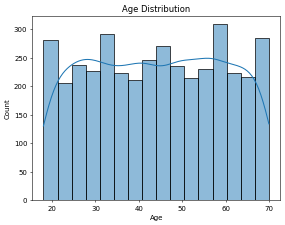

In [57]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

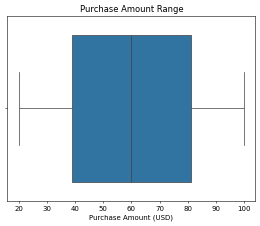

In [58]:
sns.boxplot(x=df['Purchase Amount (USD)'])
plt.title("Purchase Amount Range")
plt.show()

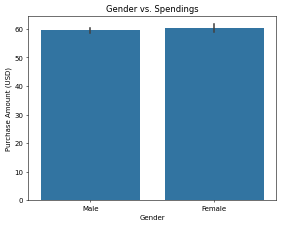

In [59]:
sns.barplot(x="Gender", y="Purchase Amount (USD)", data=df)
plt.title("Gender vs. Spendings")
plt.show()

Text(0.5, 1.0, 'Season vs. Spendings')

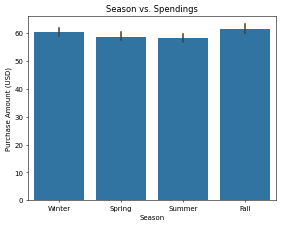

In [60]:
sns.barplot(x="Season", y="Purchase Amount (USD)", data=df)
plt.title("Season vs. Spendings")

Text(0.5, 1.0, 'Frequency of purchase and subscription status')

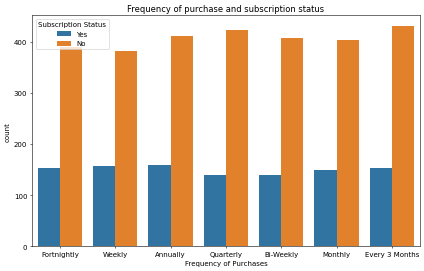

In [61]:
fig, ax = plt.subplots(figsize=(10, 6)) #for avoiding clashesh between points of X-axis.
sns.countplot(x="Frequency of Purchases", hue="Subscription Status", data=df, ax=ax)

plt.title("Frequency of purchase and subscription status")

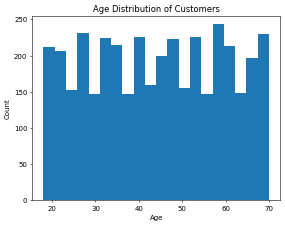

In [62]:
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


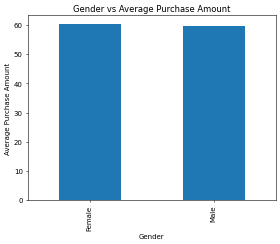

In [63]:
plt.figure()
df.groupby('Gender')['Purchase Amount (USD)'].mean().plot(kind='bar')
plt.title('Gender vs Average Purchase Amount')
plt.ylabel('Average Purchase Amount')
plt.show()


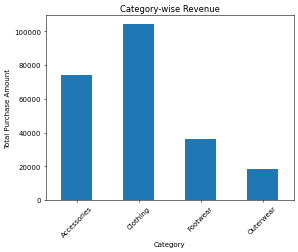

In [64]:
plt.figure()
df.groupby('Category')['Purchase Amount (USD)'].sum().plot(kind='bar')
plt.title('Category-wise Revenue')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()


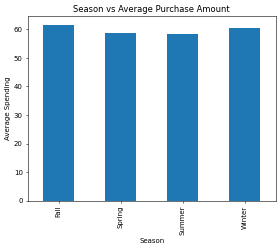

In [65]:
plt.figure()
df.groupby('Season')['Purchase Amount (USD)'].mean().plot(kind='bar')
plt.title('Season vs Average Purchase Amount')
plt.ylabel('Average Spending')
plt.show()


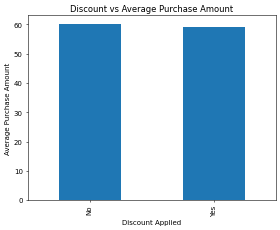

In [66]:
plt.figure()
df.groupby('Discount Applied')['Purchase Amount (USD)'].mean().plot(kind='bar')
plt.title('Discount vs Average Purchase Amount')
plt.ylabel('Average Purchase Amount')
plt.show()


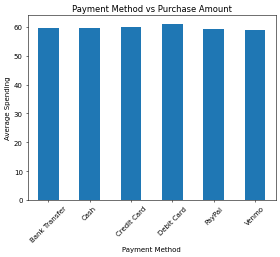

In [67]:
plt.figure()
df.groupby('Payment Method')['Purchase Amount (USD)'].mean().plot(kind='bar')
plt.title('Payment Method vs Purchase Amount')
plt.ylabel('Average Spending')
plt.xticks(rotation=45)
plt.show()


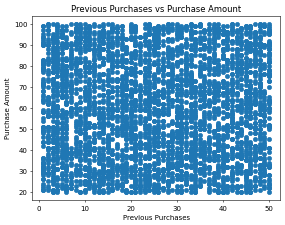

In [68]:
plt.figure()
plt.scatter(df['Previous Purchases'],
            df['Purchase Amount (USD)'])
plt.title('Previous Purchases vs Purchase Amount')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount')
plt.show()


## Age based PairPlot

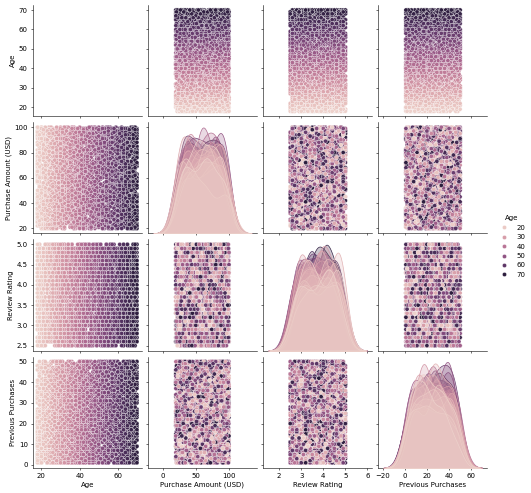

In [69]:
sns.pairplot(df,
             vars= ['Age',
             'Purchase Amount (USD)',
             'Review Rating',
             'Previous Purchases'],
            hue="Age" )


plt.show()

## Gender Based PairPlot

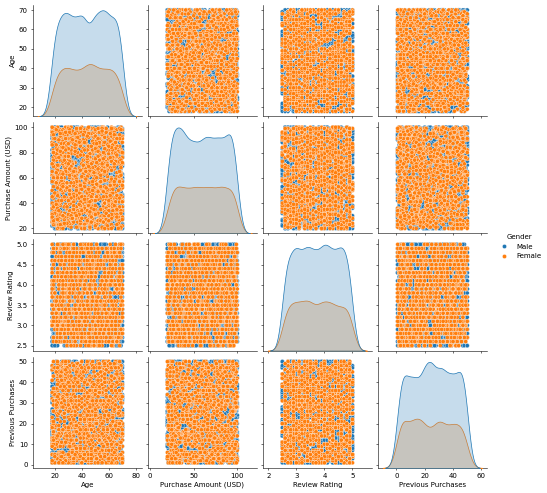

In [70]:
sns.pairplot(df,
             vars=['Age',
                   'Purchase Amount (USD)',
                   'Review Rating',
                   'Previous Purchases'],
             hue='Gender')


plt.show()
